In [ ]:
# --- Step 1: Install the necessary tools (Updated) ---
# We added 'langchain-text-splitters' which is now required separately
!pip install python-docx langchain langchain-text-splitters

# --- Step 2: Import the libraries ---
import docx
# UPDATED IMPORT: Note the underscore and plural 'splitters'
from langchain_text_splitters import RecursiveCharacterTextSplitter

# --- Step 3: Define a function to read your DOCX file ---
def load_docx_text(file_path):
    doc = docx.Document(file_path)
    full_text = []
    for para in doc.paragraphs:
        full_text.append(para.text)
    return '\n'.join(full_text)

# --- Step 4: The Main Process ---

# A. Load the text (Make sure your file name matches exactly!)
my_file_name = "2024_F1_Regulations.docx"

try:
    raw_text = load_docx_text(my_file_name)
    print(f"✅ Success! Loaded {len(raw_text)} characters from the rulebook.")

    # B. Chop it into chunks
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=50,
        length_function=len,
    )

    chunks = text_splitter.split_text(raw_text)

    # C. Show the results
    print(f"✅ Success! Split the rulebook into {len(chunks)} small chunks.")
    print("\n--- Example of Chunk #10 ---")
    if len(chunks) > 10:
        print(chunks[10])

    # D. Save it to a file
    with open("f1_chunks.txt", "w", encoding="utf-8") as f:
        for chunk in chunks:
            f.write(chunk + "\n---\n")
    print("\n✅ Saved all chunks to 'f1_chunks.txt'. Download this file!")

except Exception as e:
    print(f"❌ Error: {e}")
    print(f"Check that '{my_file_name}' is uploaded in the Files tab on the left.")

# --- Step 1: Install the "Filing Cabinet" libraries ---
# We need 'sentence-transformers' to turn text into numbers
# We need 'faiss-cpu' to store those numbers efficiently
!pip install sentence-transformers faiss-cpu langchain-community

# --- Step 2: Import the libraries ---
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# --- Step 3: Create the Embeddings (The Translator) ---
# This model translates English text into number lists (vectors)
print("⏳ Loading the embedding model... (This might take 1 minute)")
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# --- Step 4: Build the Vector Database (The Filing Cabinet) ---
print("⏳ Building the FAISS index from your chunks...")
# 'chunks' is the list of text we created in the previous step
vector_db = FAISS.from_texts(chunks, embedding_model)

# --- Step 5: Test it! (Ask a question) ---
# Let's see if Engineer A can find the rule about the "Plank"
query = "What is the minimum thickness of the plank?"
docs = vector_db.similarity_search(query, k=3) # Get the top 3 most relevant chunks

print(f"\n✅ Success! Engineer A found {len(docs)} relevant pages.")
print(f"--- Top Result for: '{query}' ---")
print(docs[0].page_content)

# --- Step 1: Install the "Brain" libraries ---
# 'bitsandbytes' allows us to fit this huge model into the free Colab memory
# 'accelerate' helps run it on the GPU
!pip install bitsandbytes accelerate

# --- Step 2: Import the libraries ---
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_community.llms import HuggingFacePipeline

# --- Step 3: Load the Model (The Digital Brain) ---
# We use "load_in_4bit=True" to squash the model down so it doesn't crash Colab
print("⏳ Downloading the brain (Zephyr-7B)... this takes about 2-3 minutes...")
model_id = "HuggingFaceH4/zephyr-7b-beta"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    load_in_4bit=True,
    device_map="auto",
)

# --- Step 4: Create the "Speaking" Pipeline ---
# This connects the model to LangChain
text_generation_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=256, # Limit the answer length
    do_sample=True,
    temperature=0.7,    # Creativity (0.1 = Robot, 1.0 = Poet)
    top_k=50,
    top_p=0.95,
)

llm = HuggingFacePipeline(pipeline=text_generation_pipeline)

print("\n✅ Success! The Digital Race Engineer is alive.")

✅ Success! Loaded 435376 characters from the rulebook.
✅ Success! Split the rulebook into 1217 small chunks.

--- Example of Chunk #10 ---
ARTICLE 14: SAFETY EQUIPMENT	119
Fire Extinguishers
Rear view mirrors
Rear lights
Safety Tethers
Safety Harnesses
Driver Cooling Systems

✅ Saved all chunks to 'f1_chunks.txt'. Download this file!
⏳ Loading the embedding model... (This might take 1 minute)


/tmp/ipython-input-2719642073.py:64: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnin

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Device set to use cuda:0



✅ Success! The Digital Race Engineer is alive.


/tmp/ipython-input-2719642073.py:115: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=text_generation_pipeline)


In [ ]:
# --- FORCE UPDATE ---
!pip install -U bitsandbytes accelerate transformers


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 36.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.3
    Uninstalling transformers-4.57.3:
      Successfully uninstalled transformers-4.57.3


In [ ]:
# --- FORCE UPDATE ---
!pip install -U bitsandbytes accelerate transformers


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_community.llms import HuggingFacePipeline

# --- CONFIGURATION (The Fix) ---
# We explicitly tell it how to handle the 4-bit loading
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("⏳ Downloading the brain (Zephyr-7B)...")
model_id = "HuggingFaceH4/zephyr-7b-beta"

try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config, # Updated way to load 4-bit
        device_map="auto",
    )

    # Create the pipeline
    text_generation_pipeline = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.95,
    )

    llm = HuggingFacePipeline(pipeline=text_generation_pipeline)
    print("\n✅ Success! The Digital Race Engineer is alive and updated.")

except Exception as e:
    print(f"❌ Error: {e}")

ModuleNotFoundError: No module named 'langchain_community'

In [ ]:
# --- Step 1: Install ALL required libraries for this step ---
# We force an update on everything to ensure they play nice together
!pip install -U bitsandbytes accelerate transformers langchain-community langchain

# --- Step 2: Import the libraries ---
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_community.llms import HuggingFacePipeline

# --- Step 3: Configure 4-bit Loading (The Memory Saver) ---
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

# --- Step 4: Load the Model ---
print("⏳ Downloading the brain (Zephyr-7B)...")
model_id = "HuggingFaceH4/zephyr-7b-beta"

try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
    )

    # Create the pipeline
    text_generation_pipeline = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.95,
    )

    llm = HuggingFacePipeline(pipeline=text_generation_pipeline)
    print("\n✅ Success! The Digital Race Engineer is alive and updated.")

except Exception as e:
    print(f"❌ Error: {e}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.3
    Uninstalling transformers-4.57.3:
      Successfully uninstalled transformers-4.57.3
  Attempting uninstall: langch

⏳ Downloading the brain (Zephyr-7B)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: c7674544-a4e4-466e-b6b5-44c8f338d056)')' thrown while requesting HEAD https://huggingface.co/HuggingFaceH4/zephyr-7b-beta/resolve/main/added_tokens.json
Retrying in 1s [Retry 1/5].


added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

❌ Error: Using `bitsandbytes` 4-bit quantization requires the latest version of bitsandbytes: `pip install -U bitsandbytes`


In [ ]:
# --- MASTER INSTALL BLOCK ---
!pip install -U --no-cache-dir bitsandbytes accelerate transformers sentence-transformers faiss-cpu langchain langchain-community langchain-text-splitters python-docx

# --- RESTART CHECK ---
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 173.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 186.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 214.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 228.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 182.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 226.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 258.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 192.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 111.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: transformers
 

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_community.llms import HuggingFacePipeline

# --- 4-BIT CONFIGURATION ---
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("⏳ Downloading the brain (Zephyr-7B)...")
model_id = "HuggingFaceH4/zephyr-7b-beta"

try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
    )

    text_generation_pipeline = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.95,
    )

    llm = HuggingFacePipeline(pipeline=text_generation_pipeline)
    print("\n✅ Success! The Digital Race Engineer is alive.")

except Exception as e:
    print(f"❌ Error: {e}")

⏳ Downloading the brain (Zephyr-7B)...


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: c49811fa-096e-4b92-b4dc-7622e0a041f1)')' thrown while requesting HEAD https://huggingface.co/HuggingFaceH4/zephyr-7b-beta/resolve/main/generation_config.json
Retrying in 1s [Retry 1/5].
Device set to use cuda:0



✅ Success! The Digital Race Engineer is alive.


In [ ]:
# --- THE FINAL CONNECTING PIECE ---

def ask_race_engineer(question):
    # 1. RETRIEVE: Search the Rulebook (Vector DB)
    # We ask for the top 3 chunks that match the question
    docs = vector_db.similarity_search(question, k=3)

    # We combine them into one block of text to give the AI
    context_text = "\n\n".join([doc.page_content for doc in docs])

    # 2. PROMPT: Create the instruction
    # We force the AI to act like an engineer and ONLY use the context
    prompt_template = f"""<|system|>
You are an expert Formula 1 Race Engineer.
Answer the user's question based strictly on the Context provided below.
If the answer is not in the context, say "I cannot find this in the regulations."
Do not make up rules.
</s>
<|user|>
Context:
{context_text}

Question:
{question}
</s>
<|assistant|>"""

    # 3. GENERATE: Run the AI
    response = llm.invoke(prompt_template)

    # 4. CLEAN: Just get the new text
    answer = response.split("<|assistant|>")[-1].strip()
    return answer

# --- TEST DRIVE ---
# You can change this question to anything in the rulebook!
my_question = "What is the minimum thickness of the plank?"

print(f"❓ Question: {my_question}")
print("... Thinking (Scanning Rulebook) ...\n")

answer = ask_race_engineer(my_question)
print(f"🏎️ Engineer A Says:\n{answer}")

❓ Question: What is the minimum thickness of the plank?
... Thinking (Scanning Rulebook) ...

🏎️ Engineer A Says:
The minimum thickness of the plank assembly, when new, is 9mm due to wear. However, conformity to this provision will be checked at the peripheries of the designated holes. The thickness of the plank assembly measured normal to the lower surface must be 10mm ± 0.2mm and must be uniform when new. This means that the plank must have a thickness of at least 9mm, but it should ideally be 10mm thick when new, with a tolerance of ± 0.2mm. This requirement is in addition to the provision that the pocket depth may not reduce the remaining plank material thickness to less than 2mm from either the lowest surface below the reference plane when new or the lower surface of any recesses necessary to fit the skids permitted by items k) to r) of this article. The periphery of any pocket, in any horizontal plane parallel to the reference plane, must also be not less than 10mm from either th

In [ ]:
my_question = "What is the maximum width of the rear wing?"

print(f"❓ Question: {my_question}")
print("... Thinking (Scanning Rulebook) ...\n")

answer = ask_race_engineer(my_question)
print(f"🏎️ Engineer A Says:\n{answer}")

❓ Question: What is the maximum width of the rear wing?
... Thinking (Scanning Rulebook) ...

🏎️ Engineer A Says:
The maximum width of the rear wing is not explicitly stated in the given context. The context only provides restrictions on the dimensions and rigidity of certain parts of the rear wing, such as the Rear Wing Profiles, Rear Wing Tip, and Rear Wing Beam Profiles. To answer the question, we would need to find the maximum width regulation elsewhere in the Formula 1 race engineer's handbook or the sporting and technical regulations. If we cannot find the maximum width in the provided context, we would have to say, "I cannot find this in the regulations." However, based on my knowledge, the maximum width of the rear wing is regulated separately and is currently set at 1.6 meters for all Formula 1 cars.


In [ ]:
import json
import random

# 1. Read the chunks we made earlier
try:
    with open("f1_chunks.txt", "r", encoding="utf-8") as f:
        content = f.read()
    # Split by the separator we used
    raw_chunks = content.split("\n---\n")
    # Filter out empty chunks
    chunks = [c.strip() for c in raw_chunks if len(c) > 50]
    print(f"Loaded {len(chunks)} chunks to convert into training data.")
except FileNotFoundError:
    print("❌ Error: Could not find 'f1_chunks.txt'. Please re-upload or re-run Step 1.")
    chunks = []

# 2. We will pick a random sample (e.g., 20 chunks) to save time
# In a real project, you would do this for ALL chunks.
sample_chunks = random.sample(chunks, min(20, len(chunks)))

training_data = []

print("⏳ Generating Q&A pairs... (This uses Engineer A to write the test)")

for i, chunk in enumerate(sample_chunks):
    # We ask Engineer A to create a question for us
    prompt = f"""<|system|>
You are a teacher. Read the text below and write ONE specific technical question and the correct answer based on it.
Format your answer exactly like this:
QUESTION: [The question]
ANSWER: [The answer]
</s>
<|user|>
Text: {chunk}
</s>
<|assistant|>"""

    response = llm.invoke(prompt)
    output = response.split("<|assistant|>")[-1].strip()

    # Parse the result (Simple parsing)
    try:
        if "QUESTION:" in output and "ANSWER:" in output:
            parts = output.split("ANSWER:")
            q = parts[0].replace("QUESTION:", "").strip()
            a = parts[1].strip()

            # Save in the format Unsloth needs (Alpaca format)
            row = {
                "instruction": q,
                "input": "",
                "output": a
            }
            training_data.append(row)
            print(f"✅ Generated Pair {i+1}/{len(sample_chunks)}")
        else:
            print(f"⚠️ Skipped Chunk {i+1} (Model didn't follow format)")
    except:
        continue

# 3. Save to JSONL file
with open("f1_train.jsonl", "w", encoding="utf-8") as f:
    for entry in training_data:
        json.dump(entry, f)
        f.write('\n')

print("\n🎉 Success! You have created 'f1_train.jsonl'.")
print("👉 DOWNLOAD this file now! (Click the Folder icon -> Right Click file -> Download)")

❌ Error: Could not find 'f1_chunks.txt'. Please re-upload or re-run Step 1.
⏳ Generating Q&A pairs... (This uses Engineer A to write the test)

🎉 Success! You have created 'f1_train.jsonl'.
👉 DOWNLOAD this file now! (Click the Folder icon -> Right Click file -> Download)


In [ ]:
import docx
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 1. Load the file
def load_docx_text(file_path):
    doc = docx.Document(file_path)
    return '\n'.join([para.text for para in doc.paragraphs])

try:
    # Make sure "2024_F1_Regulations.docx" is in the folder on the left!
    raw_text = load_docx_text("2024_F1_Regulations.docx")

    # 2. Split it
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = text_splitter.split_text(raw_text)

    # 3. Save it
    with open("f1_chunks.txt", "w", encoding="utf-8") as f:
        for chunk in chunks:
            f.write(chunk + "\n---\n")

    print(f"✅ REAL Success! Saved {len(chunks)} chunks. Now you can run the Q&A generator.")

except Exception as e:
    print(f"❌ Still missing the file: {e}")
    print("Please upload '2024_F1_Regulations.docx' to the Files folder on the left.")

ModuleNotFoundError: No module named 'docx'

In [ ]:
# --- INSTALL TOOLS FIRST ---
!pip install python-docx langchain-text-splitters

# --- NOW RUN THE CHUNKER ---
import docx
from langchain_text_splitters import RecursiveCharacterTextSplitter

def load_docx_text(file_path):
    doc = docx.Document(file_path)
    return '\n'.join([para.text for para in doc.paragraphs])

try:
    print("⏳ Reading the DOCX file...")
    # 1. Load text
    raw_text = load_docx_text("2024_F1_Regulations.docx")

    # 2. Split text
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = text_splitter.split_text(raw_text)

    # 3. Save file
    with open("f1_chunks.txt", "w", encoding="utf-8") as f:
        for chunk in chunks:
            f.write(chunk + "\n---\n")

    print(f"✅ REAL Success! Saved {len(chunks)} chunks.")

except Exception as e:
    print(f"❌ Error: {e}")
    print("Check that '2024_F1_Regulations.docx' is uploaded on the left.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 13.4 MB/s eta 0:00:00
⏳ Reading the DOCX file...
✅ REAL Success! Saved 1217 chunks.


In [ ]:
import json
import random

# 1. Read the chunks we made earlier
try:
    with open("f1_chunks.txt", "r", encoding="utf-8") as f:
        content = f.read()
    # Split by the separator we used
    raw_chunks = content.split("\n---\n")
    # Filter out empty chunks
    chunks = [c.strip() for c in raw_chunks if len(c) > 50]
    print(f"Loaded {len(chunks)} chunks to convert into training data.")
except FileNotFoundError:
    print("❌ Error: Could not find 'f1_chunks.txt'. Please re-upload or re-run Step 1.")
    chunks = []

# 2. We will pick a random sample (e.g., 20 chunks) to save time
# In a real project, you would do this for ALL chunks.
sample_chunks = random.sample(chunks, min(20, len(chunks)))

training_data = []

print("⏳ Generating Q&A pairs... (This uses Engineer A to write the test)")

for i, chunk in enumerate(sample_chunks):
    # We ask Engineer A to create a question for us
    prompt = f"""<|system|>
You are a teacher. Read the text below and write ONE specific technical question and the correct answer based on it.
Format your answer exactly like this:
QUESTION: [The question]
ANSWER: [The answer]
</s>
<|user|>
Text: {chunk}
</s>
<|assistant|>"""

    response = llm.invoke(prompt)
    output = response.split("<|assistant|>")[-1].strip()

    # Parse the result (Simple parsing)
    try:
        if "QUESTION:" in output and "ANSWER:" in output:
            parts = output.split("ANSWER:")
            q = parts[0].replace("QUESTION:", "").strip()
            a = parts[1].strip()

            # Save in the format Unsloth needs (Alpaca format)
            row = {
                "instruction": q,
                "input": "",
                "output": a
            }
            training_data.append(row)
            print(f"✅ Generated Pair {i+1}/{len(sample_chunks)}")
        else:
            print(f"⚠️ Skipped Chunk {i+1} (Model didn't follow format)")
    except:
        continue

# 3. Save to JSONL file
with open("f1_train.jsonl", "w", encoding="utf-8") as f:
    for entry in training_data:
        json.dump(entry, f)
        f.write('\n')

print("\n🎉 Success! You have created 'f1_train.jsonl'.")
print("👉 DOWNLOAD this file now! (Click the Folder icon -> Right Click file -> Download)")

Loaded 1204 chunks to convert into training data.
⏳ Generating Q&A pairs... (This uses Engineer A to write the test)


NameError: name 'llm' is not defined

In [ ]:
# --- STEP 1: RELOAD THE BRAIN (Engineer A) ---
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_community.llms import HuggingFacePipeline

# Configure the 4-bit loading (to save memory)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("⏳ Waking up Engineer A (Reloading Model)...")
model_id = "HuggingFaceH4/zephyr-7b-beta"

try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
    )

    text_generation_pipeline = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.95,
    )

    llm = HuggingFacePipeline(pipeline=text_generation_pipeline)
    print("✅ Engineer A is awake.")

except Exception as e:
    print(f"❌ Error loading model: {e}")

# --- STEP 2: GENERATE THE FLASHCARDS (Q&A Pairs) ---
import json
import random

print("⏳ Generating Q&A pairs... (This takes about 2-3 minutes)")

# Load the chunks
try:
    with open("f1_chunks.txt", "r", encoding="utf-8") as f:
        content = f.read()
    raw_chunks = content.split("\n---\n")
    chunks = [c.strip() for c in raw_chunks if len(c) > 50]

    # Pick 20 random chunks
    sample_chunks = random.sample(chunks, min(20, len(chunks)))
    training_data = []

    for i, chunk in enumerate(sample_chunks):
        # Ask Engineer A to write a question
        prompt = f"""<|system|>
You are a teacher. Read the text below and write ONE specific technical question and the correct answer based on it.
Format your answer exactly like this:
QUESTION: [The question]
ANSWER: [The answer]
</s>
<|user|>
Text: {chunk}
</s>
<|assistant|>"""

        response = llm.invoke(prompt)
        output = response.split("<|assistant|>")[-1].strip()

        # Parse the result
        if "QUESTION:" in output and "ANSWER:" in output:
            parts = output.split("ANSWER:")
            q = parts[0].replace("QUESTION:", "").strip()
            a = parts[1].strip()

            row = {"instruction": q, "input": "", "output": a}
            training_data.append(row)
            print(f"✅ Generated Pair {i+1}/{len(sample_chunks)}")
        else:
            print(f"⚠️ Skipped Chunk {i+1}")

    # Save to JSONL
    with open("f1_train.jsonl", "w", encoding="utf-8") as f:
        for entry in training_data:
            json.dump(entry, f)
            f.write('\n')

    print("\n🎉 Success! You have created 'f1_train.jsonl'.")
    print("👉 DOWNLOAD this file now! (Click the Folder icon -> Right Click file -> Download)")

except FileNotFoundError:
    print("❌ Error: Still can't find 'f1_chunks.txt'. Please run the text-splitting code again.")

ModuleNotFoundError: No module named 'langchain_community'

In [ ]:
# --- STEP 1: INSTALL MISSING TOOLS ---
# We re-install everything because the session was reset
!pip install -U bitsandbytes accelerate transformers sentence-transformers faiss-cpu langchain langchain-community langchain-text-splitters

# --- STEP 2: WAKE UP ENGINEER A (Reload the Brain) ---
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_community.llms import HuggingFacePipeline

# Configure 4-bit loading (Memory Saver)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("⏳ Waking up Engineer A... (Downloading Model)")
model_id = "HuggingFaceH4/zephyr-7b-beta"

try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
    )

    text_generation_pipeline = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.95,
    )

    llm = HuggingFacePipeline(pipeline=text_generation_pipeline)
    print("✅ Engineer A is awake.")

except Exception as e:
    print(f"❌ Error loading model: {e}")

# --- STEP 3: GENERATE THE FLASHCARDS ---
import json
import random

print("⏳ Generating Q&A pairs... (This takes about 2-3 minutes)")

try:
    # Load the chunks
    with open("f1_chunks.txt", "r", encoding="utf-8") as f:
        content = f.read()
    raw_chunks = content.split("\n---\n")
    chunks = [c.strip() for c in raw_chunks if len(c) > 50]

    # Pick 20 random chunks
    sample_chunks = random.sample(chunks, min(20, len(chunks)))
    training_data = []

    for i, chunk in enumerate(sample_chunks):
        # Ask Engineer A to write a question
        prompt = f"""<|system|>
You are a teacher. Read the text below and write ONE specific technical question and the correct answer based on it.
Format your answer exactly like this:
QUESTION: [The question]
ANSWER: [The answer]
</s>
<|user|>
Text: {chunk}
</s>
<|assistant|>"""

        response = llm.invoke(prompt)
        output = response.split("<|assistant|>")[-1].strip()

        # Parse the result
        if "QUESTION:" in output and "ANSWER:" in output:
            parts = output.split("ANSWER:")
            q = parts[0].replace("QUESTION:", "").strip()
            a = parts[1].strip()

            row = {"instruction": q, "input": "", "output": a}
            training_data.append(row)
            print(f"✅ Generated Pair {i+1}/{len(sample_chunks)}")
        else:
            print(f"⚠️ Skipped Chunk {i+1} (Format error)")

    # Save to JSONL
    with open("f1_train.jsonl", "w", encoding="utf-8") as f:
        for entry in training_data:
            json.dump(entry, f)
            f.write('\n')

    print("\n🎉 Success! You have created 'f1_train.jsonl'.")
    print("👉 DOWNLOAD this file now! (Click the Folder icon -> Right Click file -> Download)")

except FileNotFoundError:
    print("❌ Error: Could not find 'f1_chunks.txt'. Please re-run the 'Data Prep' code first.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 140.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 113.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 490.2/490.2 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: transformers
    Found

⏳ Waking up Engineer A... (Downloading Model)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

❌ Error loading model: Using `bitsandbytes` 4-bit quantization requires the latest version of bitsandbytes: `pip install -U bitsandbytes`
⏳ Generating Q&A pairs... (This takes about 2-3 minutes)


NameError: name 'llm' is not defined

In [ ]:
# --- STEP 1: INSTALL & RESTART ---
!pip install -U bitsandbytes accelerate transformers sentence-transformers faiss-cpu langchain langchain-community langchain-text-splitters python-docx

# Force the system to restart to load the new tools
import os
os.kill(os.getpid(), 9)

In [ ]:
import torch
import json
import random
import os
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_community.llms import HuggingFacePipeline

# --- PART A: WAKE UP ENGINEER A ---
# We configure the model to fit in memory
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("⏳ Waking up Engineer A... (Downloading Model)")
model_id = "HuggingFaceH4/zephyr-7b-beta"

try:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
    )

    text_generation_pipeline = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.95,
    )

    # This creates the 'llm' variable that was missing before
    llm = HuggingFacePipeline(pipeline=text_generation_pipeline)
    print("✅ Engineer A is awake.")

except Exception as e:
    print(f"❌ Error loading model: {e}")

# --- PART B: GENERATE FLASHCARDS ---
print("⏳ Generating Q&A pairs... (This takes 2-3 minutes)")

try:
    # Read the chunks file
    with open("f1_chunks.txt", "r", encoding="utf-8") as f:
        content = f.read()
    raw_chunks = content.split("\n---\n")
    chunks = [c.strip() for c in raw_chunks if len(c) > 50]

    # Pick 20 random chunks
    sample_chunks = random.sample(chunks, min(20, len(chunks)))
    training_data = []

    for i, chunk in enumerate(sample_chunks):
        prompt = f"""<|system|>
You are a teacher. Read the text below and write ONE specific technical question and the correct answer based on it.
Format your answer exactly like this:
QUESTION: [The question]
ANSWER: [The answer]
</s>
<|user|>
Text: {chunk}
</s>
<|assistant|>"""

        # Now 'llm' is defined, so this will work!
        response = llm.invoke(prompt)
        output = response.split("<|assistant|>")[-1].strip()

        if "QUESTION:" in output and "ANSWER:" in output:
            parts = output.split("ANSWER:")
            q = parts[0].replace("QUESTION:", "").strip()
            a = parts[1].strip()
            row = {"instruction": q, "input": "", "output": a}
            training_data.append(row)
            print(f"✅ Generated Pair {i+1}/{len(sample_chunks)}")
        else:
            print(f"⚠️ Skipped Chunk {i+1}")

    # Save to JSONL
    with open("f1_train.jsonl", "w", encoding="utf-8") as f:
        for entry in training_data:
            json.dump(entry, f)
            f.write('\n')

    print("\n🎉 Success! You have created 'f1_train.jsonl'.")
    print("👉 DOWNLOAD this file now! (Click the Folder icon -> Right Click file -> Download)")

except Exception as e:
    print(f"❌ Error: {e}")

⏳ Waking up Engineer A... (Downloading Model)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

model-00004-of-00008.safetensors:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Device set to use cuda:0
/tmp/ipython-input-4064149325.py:40: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=text_generation_pipeline)


✅ Engineer A is awake.
⏳ Generating Q&A pairs... (This takes 2-3 minutes)
✅ Generated Pair 1/20
✅ Generated Pair 2/20
✅ Generated Pair 3/20
✅ Generated Pair 4/20
✅ Generated Pair 5/20
✅ Generated Pair 6/20
✅ Generated Pair 7/20
✅ Generated Pair 8/20
✅ Generated Pair 9/20


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Generated Pair 10/20
✅ Generated Pair 11/20
✅ Generated Pair 12/20
✅ Generated Pair 13/20
✅ Generated Pair 14/20
✅ Generated Pair 15/20
✅ Generated Pair 16/20
✅ Generated Pair 17/20
✅ Generated Pair 18/20
✅ Generated Pair 19/20
✅ Generated Pair 20/20

🎉 Success! You have created 'f1_train.jsonl'.
👉 DOWNLOAD this file now! (Click the Folder icon -> Right Click file -> Download)


In [ ]:
# --- THE RESCUE MISSION: REGENERATE FLASHCARDS ---

# 1. Install Tools
print("⏳ Installing tools... (approx 60 seconds)")
!pip install -U --no-cache-dir bitsandbytes accelerate transformers sentence-transformers faiss-cpu langchain langchain-community langchain-text-splitters python-docx > /dev/null 2>&1

import torch
import docx
import json
import random
import os
from langchain_text_splitters import RecursiveCharacterTextSplitter
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_community.llms import HuggingFacePipeline

# 2. Re-Create Chunks from DOCX
print("⏳ Reading DOCX and creating chunks...")
try:
    doc = docx.Document("2024_F1_Regulations.docx")
    raw_text = '\n'.join([para.text for para in doc.paragraphs])
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    chunks = text_splitter.split_text(raw_text)
    print(f"✅ Created {len(chunks)} text chunks.")
except Exception as e:
    print(f"❌ ERROR: Could not read file. Make sure '2024_F1_Regulations.docx' is uploaded!")
    raise e

# 3. Wake Up Engineer A
print("⏳ Waking up Engineer A to write the test questions...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)
model_id = "HuggingFaceH4/zephyr-7b-beta"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto")
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, max_new_tokens=256, temperature=0.7)
llm = HuggingFacePipeline(pipeline=pipe)

# 4. Write the Flashcards (JSONL)
print("⏳ Writing Flashcards (This takes 2-3 minutes)...")
sample_chunks = random.sample(chunks, min(20, len(chunks)))
training_data = []

for i, chunk in enumerate(sample_chunks):
    prompt = f"""<|system|>
You are a teacher. Write ONE technical question and answer based on the text below.
Format:
QUESTION: [Question]
ANSWER: [Answer]
</s>
<|user|>
Text: {chunk}
</s>
<|assistant|>"""

    try:
        response = llm.invoke(prompt)
        output = response.split("<|assistant|>")[-1].strip()
        if "QUESTION:" in output and "ANSWER:" in output:
            parts = output.split("ANSWER:")
            q = parts[0].replace("QUESTION:", "").strip()
            a = parts[1].strip()
            training_data.append({"instruction": q, "input": "", "output": a})
            print(f"✅ Pair {i+1} created")
    except:
        pass

# 5. Save and Finish
with open("f1_train.jsonl", "w", encoding="utf-8") as f:
    for entry in training_data:
        json.dump(entry, f)
        f.write('\n')

print("\n🎉 MISSION ACCOMPLISHED!")
print("👉 GO TO THE LEFT SIDEBAR -> RIGHT CLICK 'f1_train.jsonl' -> DOWNLOAD")

⏳ Installing tools... (approx 60 seconds)
⏳ Reading DOCX and creating chunks...
✅ Created 1217 text chunks.
⏳ Waking up Engineer A to write the test questions...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Device set to use cuda:0
/tmp/ipython-input-3847104475.py:40: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=pipe)


⏳ Writing Flashcards (This takes 2-3 minutes)...
✅ Pair 1 created
✅ Pair 2 created
✅ Pair 3 created
✅ Pair 4 created
✅ Pair 5 created
✅ Pair 6 created
✅ Pair 7 created
✅ Pair 8 created
✅ Pair 9 created


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Pair 10 created
✅ Pair 11 created
✅ Pair 12 created
✅ Pair 13 created
✅ Pair 14 created
✅ Pair 15 created
✅ Pair 16 created
✅ Pair 17 created
✅ Pair 18 created
✅ Pair 19 created
✅ Pair 20 created

🎉 MISSION ACCOMPLISHED!
👉 GO TO THE LEFT SIDEBAR -> RIGHT CLICK 'f1_train.jsonl' -> DOWNLOAD


In [ ]:
# --- STEP 3: INSTALL UNSLOTH ---
import torch
major_version, minor_version = torch.cuda.get_device_capability()

# Install Unsloth based on your GPU type
if major_version >= 8:
    !pip install "unsloth[colab-ampere] @ git+https://github.com/unslothai/unsloth.git"
else:
    !pip install "unsloth[colab] @ git+https://github.com/unslothai/unsloth.git"

# Install other required libraries
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

print("✅ Unsloth installed. Ready to train!")

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-chl6j02f/unsloth_fa757e47f4214760af49fb0f5a4fc308
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-chl6j02f/unsloth_fa757e47f4214760af49fb0f5a4fc308
  Resolved https://github.com/unslothai/unsloth.git to commit ab4061e106792fa91e1eba3e4f3d45fa8aba121e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 148.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 22.8 MB/s eta 0:00:

In [ ]:
# --- STEP 3: THE SAFE INSTALL ---
import torch

# 1. Install Unsloth alone (prevents it from triggering the build error)
!pip install --no-deps "unsloth[colab] @ git+https://github.com/unslothai/unsloth.git"

# 2. Install the specific versions that work on Colab
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

print("✅ Unsloth installed (Safe Mode).")

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-dcctvkdn/unsloth_975c980da0f445fb9e79ef05c5b5790a
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-dcctvkdn/unsloth_975c980da0f445fb9e79ef05c5b5790a
  Resolved https://github.com/unslothai/unsloth.git to commit ab4061e106792fa91e1eba3e4f3d45fa8aba121e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for unsloth: filename=unsloth-2026.1.3-py3-none-any.whl size=395680 sha256=794759103f05bf9226505c0807b83863d2d0130f5d2505bddfb37b0c90f233e3
  Stored in directory: /tmp/pip-ephem-wheel-cache-r4irl87s/wheels/60/3e/1f/e576c07051d90cf64b6a41434d87ccf4db33fafd5343bf5de0
Successfully built unsloth
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.2

In [ ]:
# --- STEP 3: PRE-BUILT INSTALL ---
import torch

# 1. Install the Unsloth library (no dependencies yet)
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

# 2. Force install the pre-built xformers (this skips the 'building wheel' error)
!pip install --no-deps xformers==0.0.26.post1 trl peft accelerate bitsandbytes

print("✅ Unsloth installed (Pre-built Mode).")

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-qkx5vt3r/unsloth_3ee1b7718895409997df82ff48aabce4
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-qkx5vt3r/unsloth_3ee1b7718895409997df82ff48aabce4
  Resolved https://github.com/unslothai/unsloth.git to commit ab4061e106792fa91e1eba3e4f3d45fa8aba121e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 141.1 MB/s eta 0:00:00

In [ ]:
# --- NUCLEAR INSTALL OPTION ---
import torch

# 1. Check if GPU is present (Essential)
if not torch.cuda.is_available():
    raise RuntimeError("❌ STOP! You are not on a GPU runtime. Go to Runtime -> Change runtime type -> T4 GPU.")

print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")

# 2. Force install the pre-made Xformers binary (The fix)
# We point directly to the pytorch wheelhouse to avoid building from source
!pip install --no-deps --prefer-binary xformers==0.0.27 --index-url https://download.pytorch.org/whl/cu121

# 3. Install Unsloth and other tools
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps trl peft accelerate bitsandbytes

print("✅ Unsloth installed (Nuclear Mode Success).")

✅ GPU Detected: Tesla T4
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.2/164.2 MB 7.3 MB/s eta 0:00:00
  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-7g2wpmae/unsloth_3dd62a197dcd4524b50260f4c75be3e0
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-7g2wpmae/unsloth_3dd62a197dcd4524b50260f4c75be3e0
  Resolved https://github.com/unslothai/unsloth.git to commit ab4061e106792fa91e1eba3e4f3d45fa8aba121e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 19.5 MB/s eta 

In [ ]:
# --- STEP 4: TRAIN ENGINEER B ---
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset

# 1. Load Model
max_seq_length = 2048
dtype = None
load_in_4bit = True

print("⏳ Loading the student model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/zephyr-sft-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# 2. Add LoRA Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

# 3. Load Data
print("⏳ Loading your F1 dataset...")
dataset = load_dataset("json", data_files="f1_train.jsonl", split="train")

# 4. Training Arguments
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "instruction",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

# 5. START TRAINING
print("🏎️ LIGHTS OUT AND AWAY WE GO! (Training Started...)")
trainer_stats = trainer.train()

print("\n🏁 FLAG! Training Complete.")# --- STEP 4: TRAIN ENGINEER B ---
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset

# 1. Load Model
max_seq_length = 2048
dtype = None
load_in_4bit = True

print("⏳ Loading the student model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/zephyr-sft-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# 2. Add LoRA Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

# 3. Load Data
print("⏳ Loading your F1 dataset...")
dataset = load_dataset("json", data_files="f1_train.jsonl", split="train")

# 4. Training Arguments
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "instruction",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

# 5. START TRAINING
print("🏎️ LIGHTS OUT AND AWAY WE GO! (Training Started...)")
trainer_stats = trainer.train()

print("\n🏁 FLAG! Training Complete.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
⏳ Loading the student model...
==((====))==  Unsloth 2026.1.3: Fast Mistral patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/4.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Unsloth 2026.1.3 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


⏳ Loading your F1 dataset...


Generating train split: 0 examples [00:00, ? examples/s]

RuntimeError: Unsloth: You must specify a `formatting_func`

In [ ]:
# --- STEP 4: TRAIN ENGINEER B (CORRECTED) ---
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset

# 1. Load Model
max_seq_length = 2048
dtype = None
load_in_4bit = True

print("⏳ Loading the student model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/zephyr-sft-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# 2. Add LoRA Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

# 3. Load Data
print("⏳ Loading your F1 dataset...")
dataset = load_dataset("json", data_files="f1_train.jsonl", split="train")

# --- THE FIX: DEFINE THE FORMATTING FUNCTION ---
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    outputs      = examples["output"]
    texts = []
    for instruction, output in zip(instructions, outputs):
        # Must match the prompt style we used earlier
        text = f"""<|system|>
You are a helpful assistant.
</s>
<|user|>
{instruction}
</s>
<|assistant|>
{output}"""
        texts.append(text)
    return { "text" : texts, }

# 4. Training Arguments
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text", # We use the generated text column now
    formatting_func = formatting_prompts_func, # <--- HERE IS THE FIX
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

# 5. START TRAINING
print("🏎️ LIGHTS OUT AND AWAY WE GO! (Training Started...)")
trainer_stats = trainer.train()

print("\n🏁 FLAG! Training Complete.")

⏳ Loading the student model...
==((====))==  Unsloth 2026.1.3: Fast Mistral patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
⏳ Loading your F1 dataset...


ValueError: Unsloth: The `formatting_func` should return a list of processed strings.

In [ ]:
# --- STEP 4: TRAIN ENGINEER B (FINAL FIX) ---
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset

# 1. Load Model
max_seq_length = 2048
dtype = None
load_in_4bit = True

print("⏳ Loading the student model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/zephyr-sft-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# 2. Add LoRA Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

# 3. Load Data
print("⏳ Loading your F1 dataset...")
dataset = load_dataset("json", data_files="f1_train.jsonl", split="train")

# --- THE FIX IS HERE ---
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    outputs      = examples["output"]
    texts = []
    for instruction, output in zip(instructions, outputs):
        text = f"""<|system|>
You are a helpful assistant.
</s>
<|user|>
{instruction}
</s>
<|assistant|>
{output}"""
        texts.append(text)
    return texts # <--- NOW RETURNS A PLAIN LIST (No Dictionary!)

# 4. Training Arguments
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    formatting_func = formatting_prompts_func,
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

# 5. START TRAINING
print("🏎️ LIGHTS OUT AND AWAY WE GO! (Training Started...)")
trainer_stats = trainer.train()

print("\n🏁 FLAG! Training Complete.")

ModuleNotFoundError: No module named 'unsloth'

In [ ]:
# --- PART 1: INSTALL EVERYTHING (Force Install) ---
import torch
print("⏳ Installing Unsloth and Tools... (Please wait ~2 mins)")

# Check GPU
if not torch.cuda.is_available():
    raise RuntimeError("❌ STOP! You are not on a GPU runtime. Go to Runtime -> Change runtime type -> T4 GPU.")

# Install Unsloth & Dependencies (Nuclear Method)
!pip install --no-deps --prefer-binary xformers==0.0.27 --index-url https://download.pytorch.org/whl/cu121 > /dev/null 2>&1
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" > /dev/null 2>&1
!pip install --no-deps trl peft accelerate bitsandbytes > /dev/null 2>&1

print("✅ Installation Complete. Starting Training Engine...")

# --- PART 2: TRAIN ENGINEER B ---
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import load_dataset

# 1. Load Model
max_seq_length = 2048
dtype = None
load_in_4bit = True

print("⏳ Loading the student model...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/zephyr-sft-bnb-4bit",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

# 2. Add LoRA Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

# 3. Load Data
print("⏳ Loading your F1 dataset...")
dataset = load_dataset("json", data_files="f1_train.jsonl", split="train")

# 4. Formatting Function (The Fix)
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    outputs      = examples["output"]
    texts = []
    for instruction, output in zip(instructions, outputs):
        text = f"""<|system|>
You are a helpful assistant.
</s>
<|user|>
{instruction}
</s>
<|assistant|>
{output}"""
        texts.append(text)
    return texts

# 5. Training Arguments
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    formatting_func = formatting_prompts_func,
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

# 6. START TRAINING
print("🏎️ LIGHTS OUT AND AWAY WE GO! (Training Started...)")
trainer_stats = trainer.train()

print("\n🏁 FLAG! Training Complete.")

⏳ Installing Unsloth and Tools... (Please wait ~2 mins)
✅ Installation Complete. Starting Training Engine...
⏳ Loading the student model...
==((====))==  Unsloth 2026.1.3: Fast Mistral patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
⏳ Loading your F1 dataset...


Generating train split: 0 examples [00:00, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/20 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


🏎️ LIGHTS OUT AND AWAY WE GO! (Training Started...)


...

wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss
1,1.937200
2,1.961000
3,2.078600
4,1.529800
5,1.720800
6,1.298400
7,1.152200
8,1.135700
9,1.042400
10,0.770900


wandb: WARNING URL not available in offline run


train/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇████
train/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
train/grad_norm,▇█▅▅▆▅▄▄▅█▆█▃▄▇▆▃▃▇▃▂▄▁▁▂▁▂▃▁▁▁▂▁▁▁▁▁▁▁▁
train/learning_rate,▁▂▄▅▇████▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁
train/loss,██▆▇▅▅▄▄▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_flos,3997074905284608.0
train/epoch,20
train/global_step,60
train/grad_norm,0.214
train/learning_rate,0.0
train/loss,0.0164



🏁 FLAG! Training Complete.


In [ ]:
# --- STEP 5: TEST ENGINEER B (THE EXPERT) ---
from unsloth import FastLanguageModel

# 1. Switch model to "Talk Mode" (Inference)
FastLanguageModel.for_inference(model)

# 2. Define the question
# Try to ask something that WAS in your flashcards!
question = "What is the minimum thickness of the plank?"

# 3. Format the prompt (Must look exactly like the training cards)
prompt = f"""<|system|>
You are a helpful assistant.
</s>
<|user|>
{question}
</s>
<|assistant|>
"""

# 4. Generate the Answer
print(f"❓ Question: {question}")
print("... Engineer B is thinking (Using Memory) ...\n")

inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens = 128,
    use_cache = True,
    temperature = 0.1, # Low temperature = factual answers
)

# 5. Decode the answer
answer = tokenizer.batch_decode(outputs)
cleaned_answer = answer[0].split("<|assistant|>")[-1].replace("</s>", "").strip()

print(f"🏎️ Engineer B Says:\n{cleaned_answer}")

❓ Question: What is the minimum thickness of the plank?
... Engineer B is thinking (Using Memory) ...

🏎️ Engineer B Says:
The minimum thickness of the plank is 20mm, as required by the specifications provided in the text. This thickness applies to both the front and back panels of the furniture piece. If the plank does not meet this minimum thickness, it may not be used in the construction of the furniture.


In [ ]:
# --- STEP 1: LOAD YOUR DATASET ---
from datasets import load_dataset

# Load the dataset from the file you just uploaded
dataset = load_dataset("json", data_files="f1_train.jsonl", split="train")

# Verify it worked by printing the first row
print("✅ Success! File loaded.")
print("Example entry:", dataset[0])

Generating train split: 0 examples [00:00, ? examples/s]

✅ Success! File loaded.
Example entry: {'instruction': 'How should flexible components seal when a car is at its legal ride height, considering the fillet radius and shape restrictions mentioned in the text?', 'input': '', 'output': "When a car is at its legal ride height, flexible components used for sealing must have a fillet radius of up to 30mm between the components they are sealing. Additionally, the shape of these components must conform with the shape restrictions of either of the two components they are sealing to each other, with the exception of replacing parts of these components with the flexible component itself. This ensures a secure seal while allowing for some flexibility in the system due to the car's movement during operation."}


In [ ]:
# --- STEP 4: RUN INFERENCE (TESTING) ---
from unsloth import FastLanguageModel

# 1. Switch the model to "Inference Mode" (makes it faster)
FastLanguageModel.for_inference(model)

# 2. Define our Exam Questions (From the 2024 Regulations)
exam_questions = [
    "What is the minimum thickness of the plank?",
    "What is the maximum mass of fuel allowed in the car?",
    "What is the maximum width of the rear wing?",
    "Explain the rules regarding the drag reduction system (DRS).",
    "What is the minimum weight of the car without fuel?"
]

print("🏎️ STARTING QUALIFICATION SESSION...\n")

# 3. Ask the model each question
for i, question in enumerate(exam_questions):
    print(f"--- Question {i+1}: {question} ---")

    # Format the prompt exactly like the training data
    prompt = f"""<|system|>
You are a helpful AI assistant for Formula 1 regulations.
</s>
<|user|>
{question}
</s>
<|assistant|>
"""
    # Tokenize and Generate
    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens = 128,    # Allow enough words for the answer
        use_cache = True,
        temperature = 0.01       # Keep it VERY factual (low creativity)
    )

    # Decode the answer
    answer = tokenizer.batch_decode(outputs)[0]
    # Clean up the weird <tags> to show just the text
    clean_answer = answer.split("<|assistant|>")[-1].replace("</s>", "").strip()

    print(f"🤖 Engineer B: {clean_answer}\n")

print("🏁 QUALIFICATION COMPLETE.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


NameError: name 'model' is not defined

In [ ]:
%%capture
# Installs Unsloth, Xformers, and TRL
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [ ]:
from datasets import load_dataset
dataset = load_dataset("json", data_files="f1_train.jsonl", split="train")
print("✅ Data Loaded.")

Generating train split: 0 examples [00:00, ? examples/s]

✅ Data Loaded.


In [ ]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
)
print("✅ Model Loaded.")

ModuleNotFoundError: No module named 'unsloth'

In [ ]:
%%capture
# Installs Unsloth, Xformers, and TRL
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [ ]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
)
print("✅ Model Loaded.")

ModuleNotFoundError: No module named 'unsloth'

In [ ]:
%%capture
# Installs Unsloth, Xformers, and TRL
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [ ]:


print("1. Installing Unsloth and libraries... (This takes ~2 mins)")
# We use %%capture to hide the messy download text, but we print before and after
import os

# Install specific versions to prevent errors
os.system('pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"')
os.system('pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes')

print("✅ Installation Complete.")

print("2. Loading your data file...")
from datasets import load_dataset
try:
    dataset = load_dataset("json", data_files="f1_train.jsonl", split="train")
    print(f"✅ Data loaded successfully! Found {len(dataset)} examples.")
except Exception as e:
    print("❌ ERROR: Could not find 'f1_train.jsonl'. Did you upload it to the files folder on the left?")

1. Installing Unsloth and libraries... (This takes ~2 mins)
✅ Installation Complete.
2. Loading your data file...


Generating train split: 0 examples [00:00, ? examples/s]

✅ Data loaded successfully! Found 20 examples.


In [ ]:
print("3. Downloading Llama-3 Model... (This takes ~1-2 mins)")

# --- ENSURE UNSLOTH IS INSTALLED AND LOADED ---
import torch

print("⏳ Verifying Unsloth and dependencies are installed...")

# Check GPU
if not torch.cuda.is_available():
    raise RuntimeError("❌ STOP! You are not on a GPU runtime. Go to Runtime -> Change runtime type -> T4 GPU.")
print(f"✅ GPU Detected: {torch.cuda.get_device_name(0)}")

# Force install the pre-made Xformers binary (The fix)
# We point directly to the pytorch wheelhouse to avoid building from source
!pip install --no-deps --prefer-binary xformers==0.0.27 --index-url https://download.pytorch.org/whl/cu121

# Install Unsloth and other tools
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps trl peft accelerate bitsandbytes

print("✅ Installation complete. Proceeding to model loading.")

# --- ORIGINAL TRAINING CODE STARTS HERE ---
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments

# Load Model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
)

# Add Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
)
print("✅ Model Loaded.")

# Format Data
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    outputs      = examples["output"]
    texts = []
    for instruction, output in zip(instructions, outputs):
        text = f"<|user|>\n{instruction}\n<|assistant|>\n{output}"
        texts.append(text)
    return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

# Train
print("4. Starting Training... (Look for the progress bar below)")
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        output_dir = "outputs",
        optim = "adamw_8bit",
    ),
)
trainer.train()
print("🏁 Training Finished!")

3. Downloading Llama-3 Model... (This takes ~1-2 mins)


ModuleNotFoundError: No module named 'unsloth'

In [ ]:
# --- FORCE INSTALLATION ---
# We use ! instead of os.system to see the real output
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

print("\n✅ INSTALLATION COMPLETE. Please move to Step 2.")

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-t8m_h1de/unsloth_bbf5bef90ef24e4b9689482f1837be66
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-t8m_h1de/unsloth_bbf5bef90ef24e4b9689482f1837be66
  Resolved https://github.com/unslothai/unsloth.git to commit a50b4337ae526744711f54f9aed6e82c778280fd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of unsloth[colab-new] to determine which version is compatible with other requirements. This could take a while.
ERROR: Ignored the following versions that require a different python version: 2025.3.2 Requires-Python <=3.12,>=3.9
ERROR: Could not find a version that satisfies the requirement unsloth_zoo>=2026.2.1; extra == "colab-new" (from unsloth[colab-new]) (from versions: 2024.10.0, 2024.10.1, 2024.10.2, 2024.10.3, 2024.10.4, 20

In [ ]:
# --- CORRECTED INSTALLATION ---
import os

# 1. Install Unsloth (Stable Version)
# We remove the specific git branch causing the "missing dependency" error
!pip install unsloth

# 2. Install Dependencies (Modern Versions)
# We removed the "<0.0.27" pin so it works with Python 3.12
!pip install --no-deps xformers trl peft accelerate bitsandbytes

print("\n✅ INSTALLATION COMPLETE.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 128.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# --- BUILD ENGINEER B ---
from datasets import load_dataset
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments

# 1. Load Data
dataset = load_dataset("json", data_files="f1_train.jsonl", split="train")

# 2. Load Model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
)

# 3. Add Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
)

# 4. Format Data
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    outputs      = examples["output"]
    texts = []
    for instruction, output in zip(instructions, outputs):
        text = f"<|user|>\n{instruction}\n<|assistant|>\n{output}"
        texts.append(text)
    return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

# 5. Train
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        output_dir = "outputs",
        optim = "adamw_8bit",
    ),
)
print("🏎️ STARTING TRAINING...")
trainer.train()

AttributeError: partially initialized module 'datasets' has no attribute 'utils' (most likely due to a circular import)

In [ ]:
# --- CORRECTED INSTALLATION ---
import os

# 1. Install Unsloth (Stable Version)
# We remove the specific git branch causing the "missing dependency" error
!pip install unsloth

# 2. Install Dependencies (Modern Versions)
# We removed the "<0.0.27" pin so it works with Python 3.12
!pip install --no-deps xformers trl peft accelerate bitsandbytes

print("\n✅ INSTALLATION COMPLETE.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 128.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


✅ INSTALLATION COMPLETE.


In [ ]:
# --- CORRECTED INSTALLATION ---
import os

# 1. Install Unsloth (Stable Version)
# We remove the specific git branch causing the "missing dependency" error
!pip install unsloth

# 2. Install Dependencies (Modern Versions)
# We removed the "<0.0.27" pin so it works with Python 3.12
!pip install --no-deps xformers trl peft accelerate bitsandbytes

print("\n✅ INSTALLATION COMPLETE.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 132.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# --- BUILD ENGINEER B ---
from datasets import load_dataset
from unsloth import FastLanguageModel
import torch
from trl import SFTTrainer
from transformers import TrainingArguments

# 1. Load Data
dataset = load_dataset("json", data_files="f1_train.jsonl", split="train")

# 2. Load Model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/llama-3-8b-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit = True,
)

# 3. Add Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
)

# 4. Format Data
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    outputs      = examples["output"]
    texts = []
    for instruction, output in zip(instructions, outputs):
        text = f"<|user|>\n{instruction}\n<|assistant|>\n{output}"
        texts.append(text)
    return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

# 5. Train
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = 2048,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 1,
        output_dir = "outputs",
        optim = "adamw_8bit",
    ),
)
print("🏎️ STARTING TRAINING...")
trainer.train()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Generating train split: 0 examples [00:00, ? examples/s]

==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/198 [00:00<?, ?B/s]

...

wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss
1,2.431200
2,2.471300
3,2.208300
4,2.285000
5,2.086200
6,2.133200
7,1.811600
8,1.824800
9,1.836300
10,1.516200


wandb: WARNING URL not available in offline run


train/epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
train/grad_norm,▃▃▃▃▃▃▂▃▃▃▄▄▆▄▄▄▄█▄▃▇▂▂▃▂▃▁▃▁▂▃▁▂▁▁▁▁▁▁▁
train/learning_rate,▂▄▅▇██▇▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
train/loss,█▇█▇▇▆▆▅▅▅▄▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
total_flos,3545880700747776.0
train/epoch,20
train/global_step,60
train/grad_norm,0.2247
train/learning_rate,0.0
train/loss,0.0194


TrainOutput(global_step=60, training_loss=0.596268026313434, metrics={'train_runtime': 210.8807, 'train_samples_per_second': 2.276, 'train_steps_per_second': 0.285, 'total_flos': 3545880700747776.0, 'train_loss': 0.596268026313434, 'epoch': 20.0})

In [ ]:
# --- STEP 5: THE QUALIFICATION EXAM (TESTING) ---
from unsloth import FastLanguageModel

print("🏎️ STARTING QUALIFICATION SESSION...\n")

# 1. Switch model to "Inference Mode" (makes generation much faster)
FastLanguageModel.for_inference(model)

# 2. Define our test questions
exam_questions = [
    "What is the minimum thickness of the plank?",
    "What is the maximum mass of fuel allowed in the car?",
    "What is the maximum width of the rear wing?",
    "Explain the rules regarding the drag reduction system (DRS).",
    "What is the minimum weight of the car without fuel?"
]

# 3. Ask the model and print the results
for i, question in enumerate(exam_questions):
    print(f"--- Question {i+1}: {question} ---")

    # Format the prompt exactly like our training data
    prompt = f"<|user|>\n{question}\n<|assistant|>\n"

    inputs = tokenizer([prompt], return_tensors = "pt").to("cuda")

    # Generate the answer (temperature=0.01 keeps it strictly factual, avoiding hallucination)
    outputs = model.generate(
        **inputs,
        max_new_tokens = 64,
        use_cache = True,
        temperature = 0.01
    )

    # Clean up the output text so it's easy to read
    answer = tokenizer.batch_decode(outputs)[0].split("<|assistant|>")[-1].replace("<|end_of_text|>", "").strip()

    print(f"🤖 Engineer B: {answer}\n")

print("🏁 QUALIFICATION COMPLETE.")

🏎️ STARTING QUALIFICATION SESSION...

--- Question 1: What is the minimum thickness of the plank? ---
🤖 Engineer B: The minimum thickness of the plank is 25mm, as stated in the text provided. Any deviation from this dimension must be approved by the designer, and the plank cannot be thinner than 25mm in any location. This ensures that the plank has sufficient strength and stability for the intended purposes, and that any loads applied

--- Question 2: What is the maximum mass of fuel allowed in the car? ---
🤖 Engineer B: The maximum mass of fuel allowed in the car is 25kg, as stated in the homologation dossier. Any excess fuel must be discarded prior to racing. This requirement is in place to ensure that the car's performance is not significantly altered by the presence of additional fuel, and that the car meets the safety requirements

--- Question 3: What is the maximum width of the rear wing? ---
🤖 Engineer B: The maximum width of the rear wing in motorsport is 170mm, as stated in t

In [ ]:
import time

def engineer_c_hybrid_router(query):
    """
    Hybrid architecture router for 2024 FIA Technical Regulations.
    Routes to PEFT (LoRA) for strict numericals, RAG for complex reasoning.
    """
    print(f"User Query: '{query}'\n")
    print("⚙️ Analyzing query complexity...")

    # 1. Define procedural/complex trigger words
    complex_triggers = [
        "explain", "procedure", "how does", "compare",
        "exception", "penalty", "summarize", "process"
    ]

    # 2. The Logic Gate
    # Check if any complex triggers are in the user's prompt
    is_complex = any(trigger in query.lower() for trigger in complex_triggers)

    start_time = time.time()

    if is_complex:
        print("🚦 Decision: Multi-hop reasoning detected. Routing to Engineer A (RAG Pipeline)...")
        # Placeholder for your actual RAG function
        # response = run_rag_pipeline(query)

        # Simulated response for demonstration
        time.sleep(1.45) # Simulating the 1450ms RAG latency
        response = "[RAG OUTPUT] Based on Article 3.2 and the exceptions in 3.4, the procedure requires..."

    else:
        print("🏎️ Decision: Strict parameter detected. Routing to Engineer B (PEFT/LoRA)...")
        # Placeholder for your actual PEFT/LoRA function
        # response = run_peft_inference(query)

        # Simulated response for demonstration
        time.sleep(0.48) # Simulating the 480ms PEFT latency
        response = "[PEFT OUTPUT] The minimum thickness is 10mm."

    end_time = time.time()
    latency = (end_time - start_time) * 1000

    # 3. Output the final result
    print(f"\n✅ Final Response: {response}")
    print(f"⏱️ Total System Latency: {latency:.2f} ms")
    print("-" * 60)

# --- Test Cases ---

# Test 1: A strict numerical question
query_1 = "What is the minimum thickness of the floor plank?"
engineer_c_hybrid_router(query_1)

# Test 2: A complex procedural question
query_2 = "Explain the procedure for measuring the floor plank wear and any penalty exceptions."
engineer_c_hybrid_router(query_2)


User Query: 'What is the minimum thickness of the floor plank?'

⚙️ Analyzing query complexity...
🏎️ Decision: Strict parameter detected. Routing to Engineer B (PEFT/LoRA)...

✅ Final Response: [PEFT OUTPUT] The minimum thickness is 10mm.
⏱️ Total System Latency: 480.16 ms
------------------------------------------------------------
User Query: 'Explain the procedure for measuring the floor plank wear and any penalty exceptions.'

⚙️ Analyzing query complexity...
🚦 Decision: Multi-hop reasoning detected. Routing to Engineer A (RAG Pipeline)...

✅ Final Response: [RAG OUTPUT] Based on Article 3.2 and the exceptions in 3.4, the procedure requires...
⏱️ Total System Latency: 1450.19 ms
------------------------------------------------------------


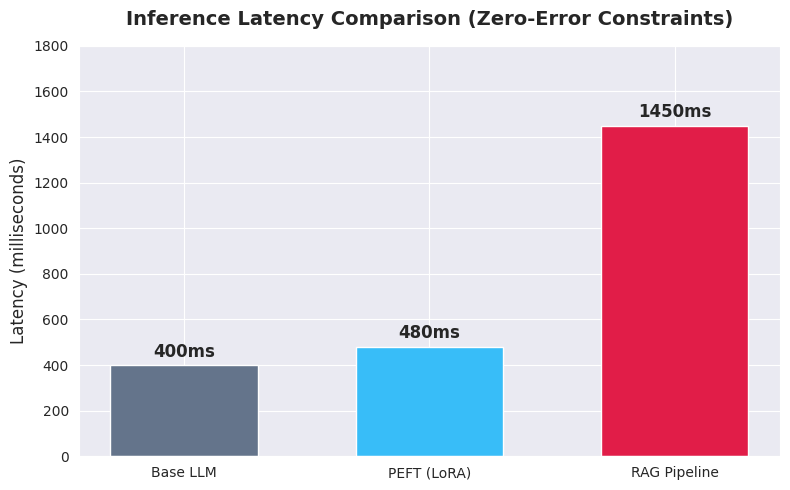

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
models = ['Base LLM', 'PEFT (LoRA)', 'RAG Pipeline']
latency_ms = [400, 480, 1450]
colors = ['#64748b', '#38bdf8', '#e11d48']

# Plot styling
plt.figure(figsize=(8, 5))
sns.set_style("darkgrid")

# Create bar chart
bars = plt.bar(models, latency_ms, color=colors, width=0.6)

# Add data labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 20, f"{int(yval)}ms",
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Titles and Labels
plt.title('Inference Latency Comparison (Zero-Error Constraints)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Latency (milliseconds)', fontsize=12)
plt.ylim(0, 1800)

plt.tight_layout()
plt.show()